In [6]:
from pathlib import Path
import numpy as np

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

In [7]:
# Dataset Path
dataset_path = Path(
    "/Users/amirhossein/.cache/kagglehub/datasets/"
    "unclesamulus/blood-cells-image-dataset/"
    "versions/2/bloodcells_dataset"
)

dataset_path.exists()

True

In [ ]:
# Define Image Transforms
image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(), # conver image to numbers so PyTorch can understand
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
# Create one dataset just to get labels
base_dataset = datasets.ImageFolder(root=dataset_path)

class_names = base_dataset.classes
targets = base_dataset.targets

class_names

['basophil',
 'eosinophil',
 'erythroblast',
 'ig',
 'lymphocyte',
 'monocyte',
 'neutrophil',
 'platelet']

In [9]:
# Train/Validation/Test Split
indices = np.arange(len(base_dataset))

train_idx, temp_idx, train_y, temp_y = train_test_split(
    indices,
    targets,
    test_size=0.30,
    random_state=42,
    stratify=targets
)

val_idx, test_idx, val_y, test_y = train_test_split(
    temp_idx,
    temp_y,
    test_size=0.50,
    random_state=42,
    stratify=temp_y
)

len(train_idx), len(val_idx), len(test_idx)

(11964, 2564, 2564)

In [10]:
# Create separate datasets with separate transforms
train_full = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

val_full = datasets.ImageFolder(
    root=dataset_path,
    transform=test_transform
)

test_full = datasets.ImageFolder(
    root=dataset_path,
    transform=test_transform
)

In [11]:
#Apply the split indices
train_dataset = Subset(train_full, train_idx)
val_dataset = Subset(val_full, val_idx)
test_dataset = Subset(test_full, test_idx)

In [12]:
# Create DataLoaders
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [13]:
# Check one batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Class names:", class_names)

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Class names: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


In [14]:
import matplotlib.pyplot as plt

In [ ]:
# Unnormalize helper function
def unnormalize(img):

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    img = img * std + mean

    img = img.clamp(0,1)

    return img

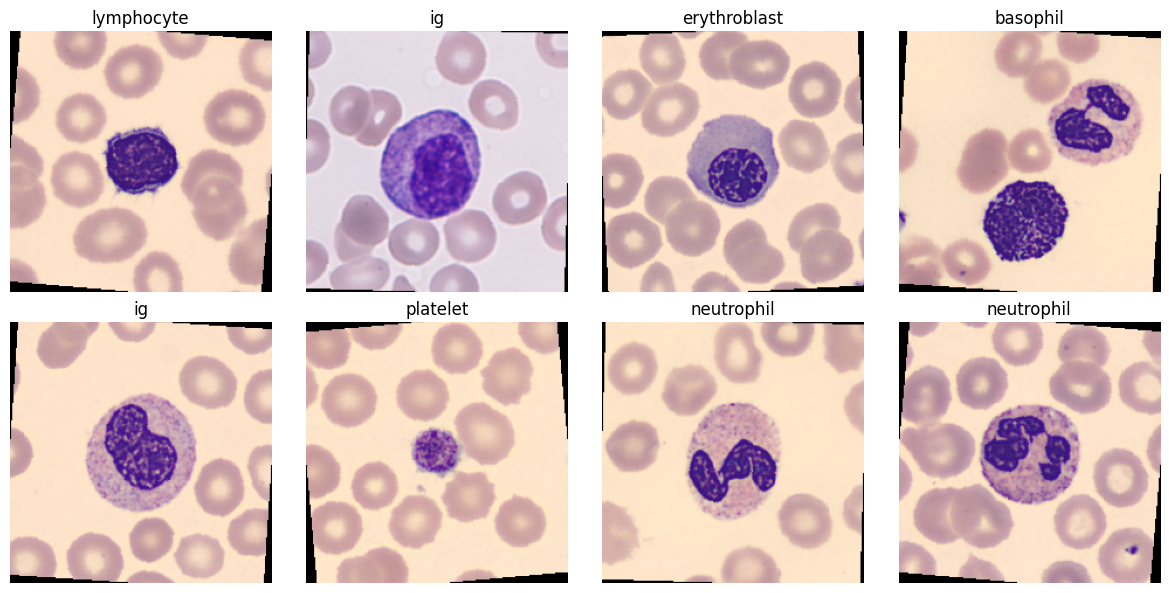

In [16]:
# Display 8 transformed images
fig, axes = plt.subplots(2, 4, figsize=(12,6))

axes = axes.flatten()

for i in range(8):

    img = unnormalize(images[i])

    img = img.permute(1,2,0).numpy()

    axes[i].imshow(img)

    class_name = class_names[labels[i]]

    axes[i].set_title(class_name)

    axes[i].axis("off")

plt.tight_layout()
plt.show()